# 📉 Telco Customer Churn — End-to-End ML Analysis

This notebook walks through the **full, upgraded** churn-prediction workflow:
data cleaning → EDA → feature engineering → **5-model comparison** →
**cross-validation** → **hyperparameter tuning** → **threshold optimization** →
**explainability (SHAP + permutation importance)** → business recommendations.

All heavy lifting lives in reusable modules under `src/`; this notebook narrates
and visualizes the results. Every number below is computed live — nothing is
hand-typed.

**Author:** Naveen

## 1. Business Problem

A telecom company loses recurring revenue whenever a customer cancels. Acquiring
a new customer costs far more than keeping one, so even a small churn reduction is
valuable. **Goal:** rank customers by churn risk *and* explain the drivers, so the
retention team can act before customers leave. Because missing a churner usually
costs more than a wasted offer, we ultimately **tune the decision threshold for recall/F1**.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
# Run from the project root so relative data/figure paths resolve.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, "src")

import pandas as pd, numpy as np
pd.set_option("display.max_columns", 50)

from data_preprocessing import load_data, clean_data, get_feature_target
from feature_engineering import add_engineered_features, split_column_types
from model_training import train_and_compare, save_artifacts, get_best_threshold, text_report
import visualization as viz
import explainability as expl
print("Modules imported.")

Modules imported.


## 2. Load & Inspect the Raw Data

In [2]:
raw = load_data("data/raw/Telco-Customer-Churn.csv")
print("Shape:", raw.shape)
raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Data-quality issue: TotalCharges is stored as text and has 11 blanks (tenure=0 customers)
blanks = (raw["TotalCharges"].astype(str).str.strip() == "").sum()
print(f"Blank TotalCharges values: {blanks}")
print("\nRaw churn distribution:")
print(raw["Churn"].value_counts())

Blank TotalCharges values: 11

Raw churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


## 3. Clean the Data

`clean_data` drops the `customerID`, converts `TotalCharges` to numeric (imputing the
11 blanks with 0, since those customers have tenure 0 and were never billed), and
encodes the target to 1/0.

In [4]:
clean = clean_data(raw)
print(f"Rows: {len(clean):,} | Churn rate: {clean['Churn'].mean():.3f} (imbalanced ~26.5%)")
clean.head()

Rows: 7,043 | Churn rate: 0.265 (imbalanced ~26.5%)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 4. Exploratory Data Analysis

We generate the EDA figures into `reports/figures/` and display them inline.

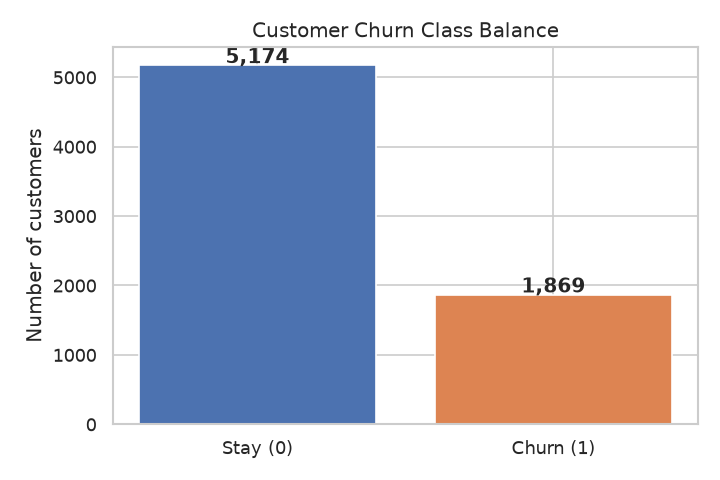

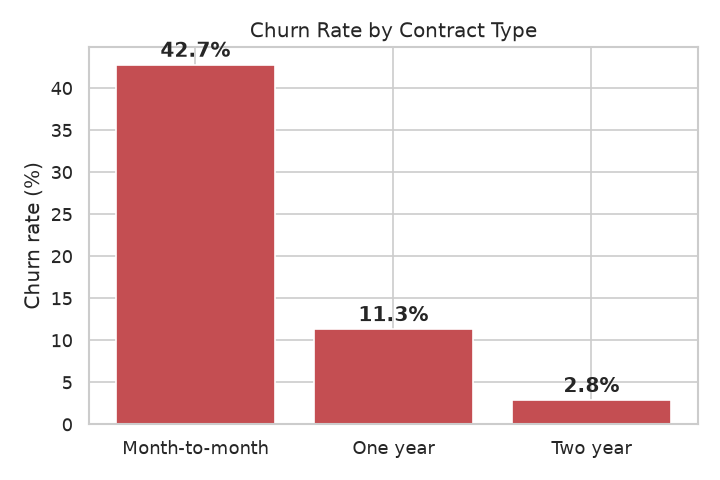

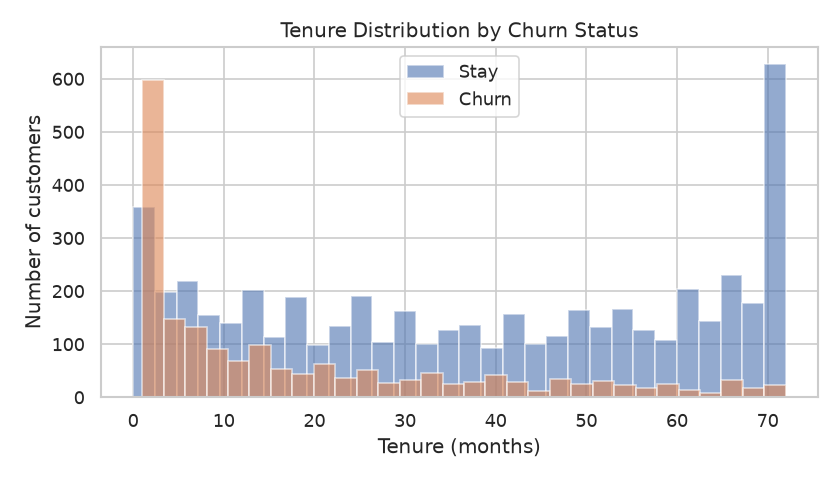

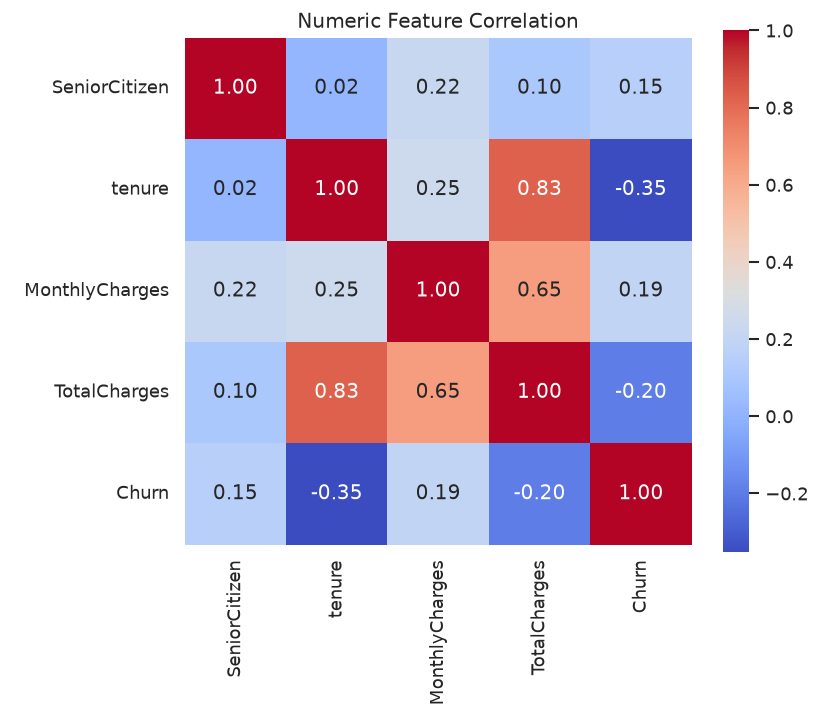

In [5]:
viz.plot_churn_balance(clean)
viz.plot_churn_by_contract(clean)
viz.plot_tenure_distribution(clean)
viz.plot_correlation_heatmap(clean)

from IPython.display import Image, display
for f in ["churn_balance", "churn_by_contract", "tenure_distribution", "correlation_heatmap"]:
    display(Image(f"reports/figures/{f}.png"))

**Takeaways:** churn is concentrated in **month-to-month** contracts and in
**short-tenure** customers. Monthly charges and total charges are correlated with tenure,
which motivates the engineered features below.

## 5. Feature Engineering

`add_engineered_features` adds business-motivated features:
- `tenure_group` — binned customer lifetime
- `avg_monthly_spend` — normalized spend (`TotalCharges / tenure`)
- `has_streaming` — streaming TV or movies
- `num_addon_services` — count of protective add-ons (security/backup/protection/support)

Preprocessing (impute → scale → one-hot encode) is wrapped in a `ColumnTransformer`
so it is **fit only on training folds** (no leakage) and deploys as one object.

In [6]:
X, y = get_feature_target(clean)
X = add_engineered_features(X)
num_cols, cat_cols = split_column_types(X)
print(f"Total features: {X.shape[1]}")
print(f"Numeric ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")
X[["tenure_group", "avg_monthly_spend", "has_streaming", "num_addon_services"]].head()

Total features: 23
Numeric (7): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'has_streaming', 'num_addon_services']
Categorical (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


,tenure_group,avg_monthly_spend,has_streaming,num_addon_services
0,0-12,29.85,0,1
1,24-48,55.57,0,2
2,0-12,54.08,0,2
3,24-48,40.91,0,3
4,0-12,75.82,0,0


## 6. Train, Cross-Validate, Tune & Compare Five Models

`train_and_compare` builds a leak-free pipeline for each model, estimates ROC-AUC with
**5-fold stratified cross-validation**, runs **RandomizedSearchCV** on the tree/boosting
models, handles imbalance (class weights / `scale_pos_weight`), and **tunes the decision
threshold for F1** (chosen on train, applied to test).

> Set `tune=False` for a fast smoke run; here we run the full tuned comparison.

In [7]:
results, fitted, (X_train, X_test, y_train, y_test) = train_and_compare(X, y, tune=True)

comparison = pd.DataFrame([{
    "Model": r.name, "Accuracy": r.accuracy, "Precision": r.precision,
    "Recall": r.recall, "F1": r.f1, "ROC-AUC": r.roc_auc,
    "CV ROC-AUC": f"{r.cv_roc_auc_mean:.3f} ± {r.cv_roc_auc_std:.3f}",
    "Threshold": r.threshold, "Tuned": r.tuned,
} for r in results])
comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,CV ROC-AUC,Threshold,Tuned
0,Gradient Boosting,0.7658,0.5430,0.7433,0.6275,0.8465,0.849 ± 0.013,0.320,True
1,LightGBM,0.7736,0.5560,0.7299,0.6312,0.8457,0.845 ± 0.009,0.581,True
2,Random Forest,0.7736,0.5560,0.7299,0.6312,0.8445,0.847 ± 0.011,0.569,True
3,XGBoost,0.7672,0.5469,0.7166,0.6204,0.8428,0.845 ± 0.011,0.570,True
4,Logistic Regression,0.7779,0.5656,0.7032,0.6269,0.8424,0.846 ± 0.011,0.607,False


The models are close on ROC-AUC (~0.84–0.85) with overlapping CV bands — no model is
dramatically better on this dataset. We select the best by **test ROC-AUC**.

In [8]:
best_name, payload = save_artifacts(results, fitted)
best_thr = get_best_threshold(results, best_name)
print(f"Best model: {best_name}")
print(f"Tuned decision threshold: {best_thr}")
print("Best params:", next(r.best_params for r in results if r.name == best_name))

Best model: Gradient Boosting
Tuned decision threshold: 0.32
Best params: {'subsample': 0.9, 'n_estimators': 250, 'max_depth': 2, 'learning_rate': 0.05}


## 7. Evaluate the Best Model

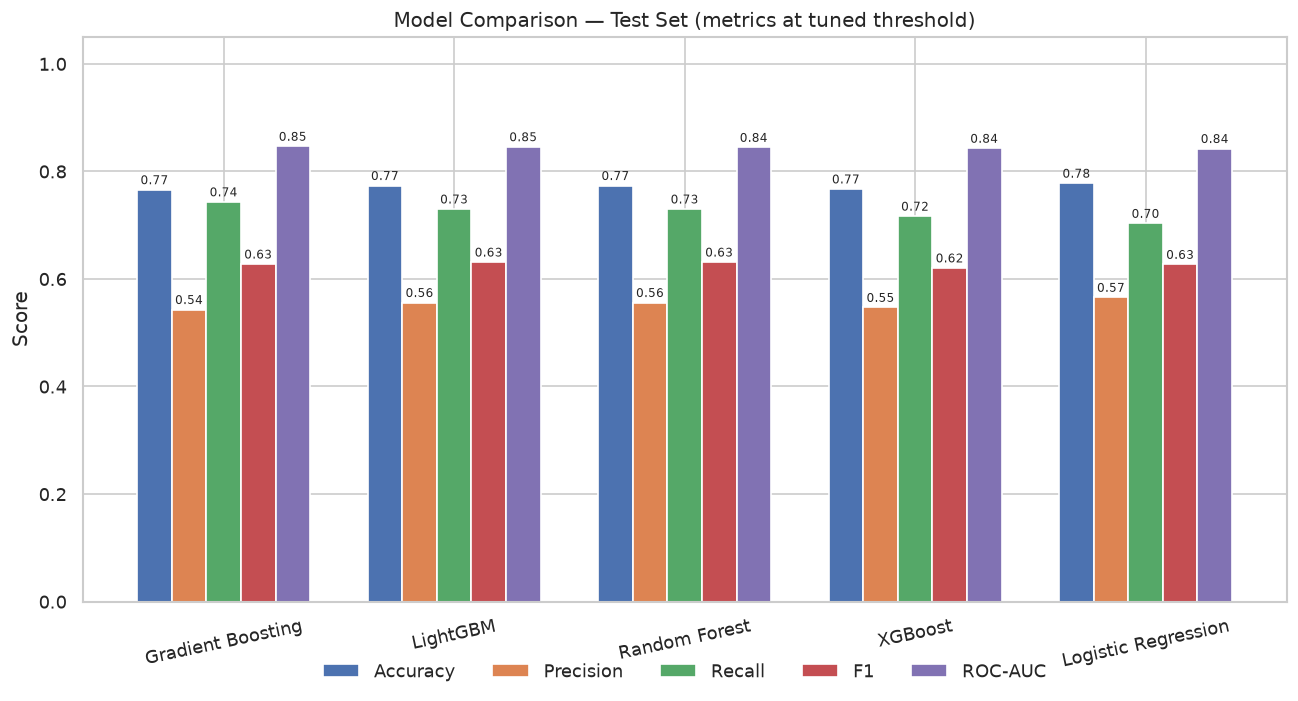

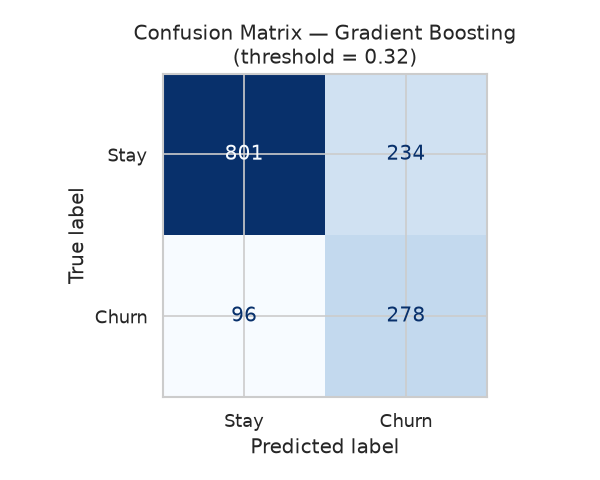

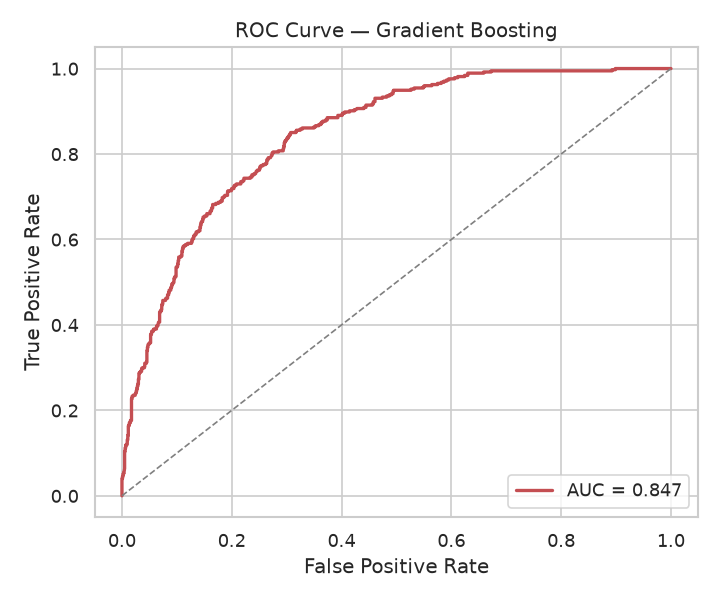

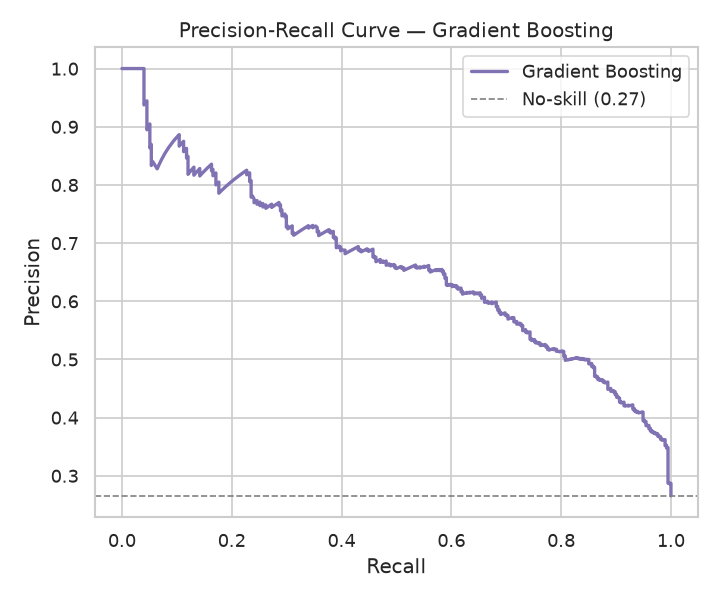

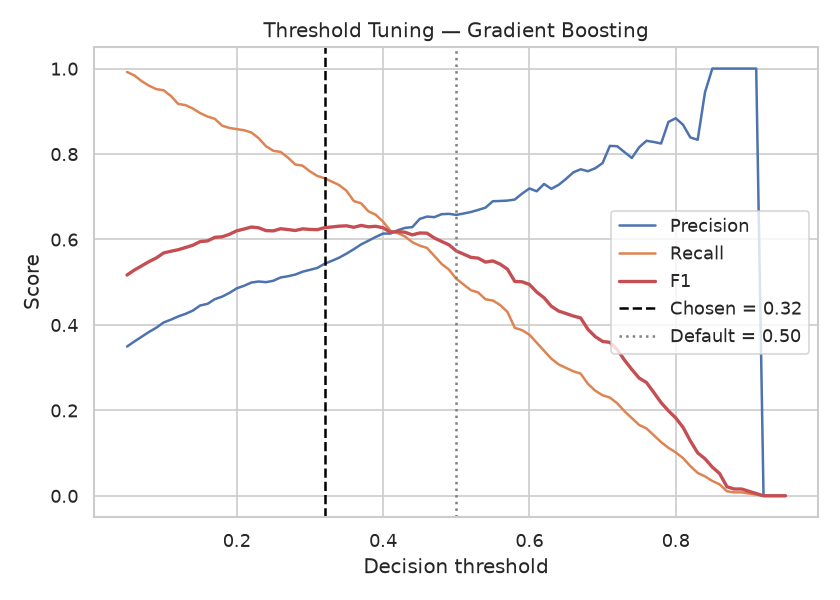

In [9]:
best_pipe = fitted[best_name]
viz.plot_model_comparison(results)
viz.plot_confusion_matrix(best_pipe, X_test, y_test, best_name, threshold=best_thr)
viz.plot_roc_curve(best_pipe, X_test, y_test, best_name)
viz.plot_precision_recall_curve(best_pipe, X_test, y_test, best_name)
viz.plot_threshold_tuning(best_pipe, X_test, y_test, best_thr, best_name)

for f in ["model_comparison", "confusion_matrix", "roc_curve",
          "precision_recall_curve", "threshold_tuning"]:
    display(Image(f"reports/figures/{f}.png"))

In [10]:
print(text_report(best_pipe, X_test, y_test, threshold=best_thr))

              precision    recall  f1-score   support

        Stay       0.89      0.77      0.83      1035
       Churn       0.54      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409

Confusion matrix [rows=actual, cols=pred] @ threshold=0.320:
[[801 234]
 [ 96 278]]


**Why threshold tuning matters:** at the default 0.5 the boosting model has high
precision but mediocre recall. Lowering the threshold (to ~0.32) trades some precision
for substantially higher **recall** — we catch more churners, which is the costly error
to miss in a retention context.

## 8. Explainability — Why does the model predict churn?

Two complementary, model-agnostic methods. Agreement between them builds trust.

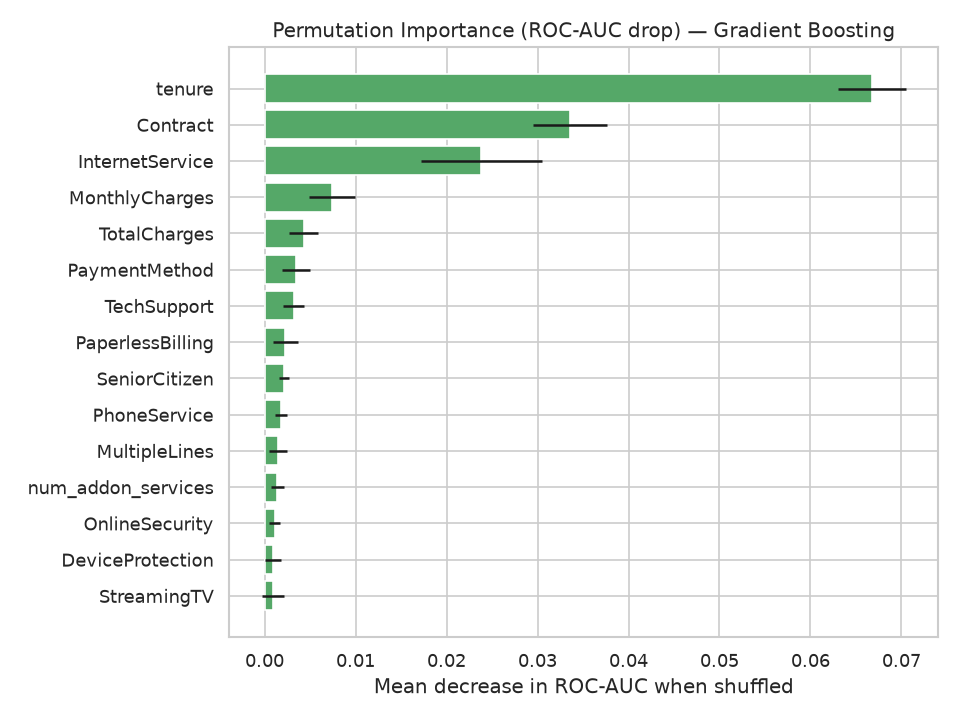

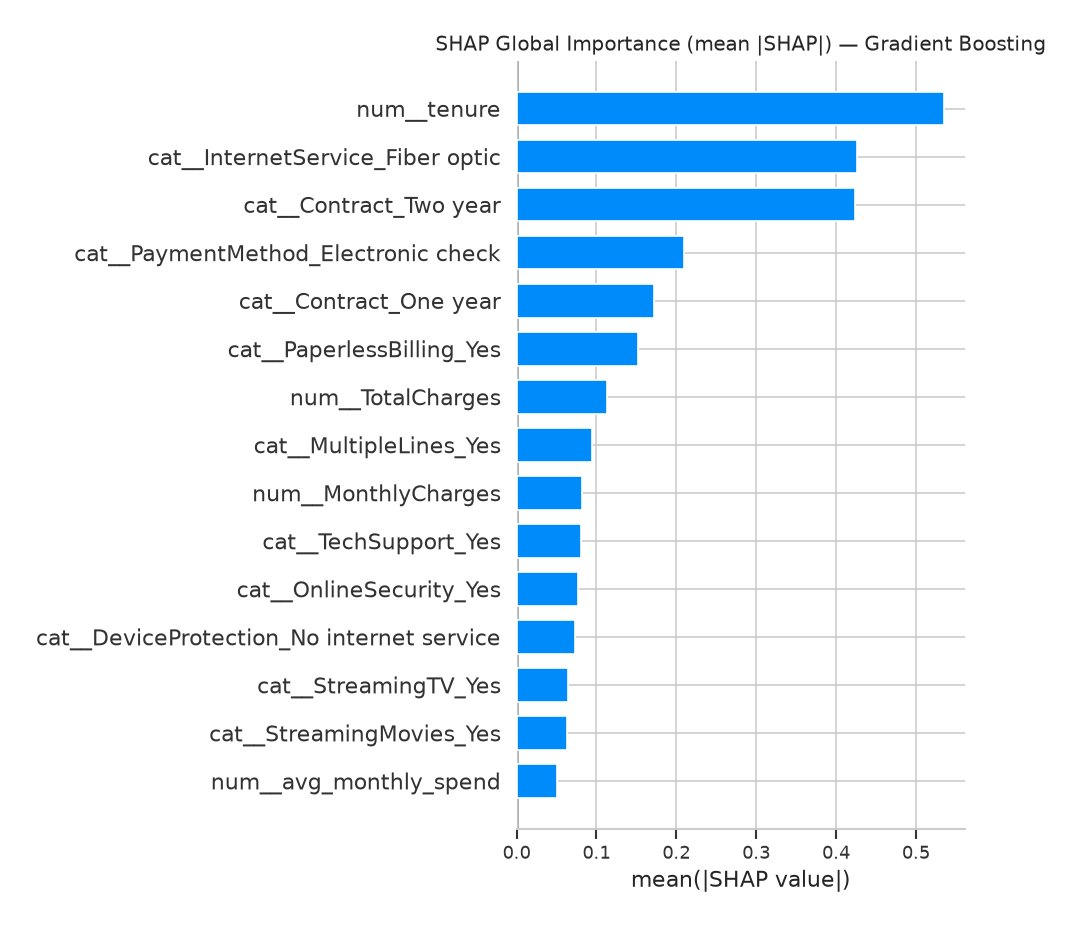

In [11]:
viz.plot_feature_importance(best_pipe, best_name)
expl.permutation_importance_plot(best_pipe, X_test, y_test, best_name)
expl.shap_summary_plot(best_pipe, X_train, X_test, best_name)

for f in ["permutation_importance", "shap_summary"]:
    display(Image(f"reports/figures/{f}.png"))

In [12]:
# Tidy table of the strongest drivers (permutation importance on the test set)
drivers = expl.top_drivers_table(best_pipe, X_test, y_test, top_n=10)
drivers

,feature,importance_mean,importance_std
0,tenure,0.066798,0.003721
1,Contract,0.033592,0.004048
2,InternetService,0.023835,0.006659
3,MonthlyCharges,0.007416,0.002533
4,TotalCharges,0.004310,0.001597
5,PaymentMethod,0.003443,0.001572
6,TechSupport,0.003199,0.001188
7,PaperlessBilling,0.002264,0.001375
8,SeniorCitizen,0.002125,0.000508
9,PhoneService,0.001799,0.000674


## 9. Key Insights & Business Recommendations

**Top churn drivers** (SHAP + permutation importance agree):
- **Short tenure** — the first year is the most fragile period.
- **Month-to-month contracts** — by far the highest-churn segment.
- **Fiber-optic internet** and **electronic-check payments** raise churn risk.
- **Missing tech-support / online-security** add-ons increase risk.

**Recommended actions:**
1. Incentivize month-to-month customers onto annual contracts.
2. Launch an early-life onboarding/retention program in the first 12 months.
3. Promote auto-pay over electronic check.
4. Bundle tech-support / security add-ons, especially for fiber customers.

**Operationalize:** score the active base monthly with `models/churn_model.joblib`, apply
the tuned probability threshold, and route the highest-risk customers into retention
campaigns. The threshold is a business lever (precision vs. recall vs. budget).

## 10. Reproducibility

- Everything here is regenerated by `python src/main.py` (or `--fast` to skip tuning).
- Results depend on `RANDOM_STATE = 42` and the search budget, so they are reproducible.
- No metrics are hand-typed — they come straight from the fitted pipelines.